# Classification and Logistic Regression

This notebook demonstrates core classification concepts using the Iris dataset. It covers feature normalisation, binary logistic regression, cross-entropy loss, gradient descent, decision boundaries, one-vs-all multiclass classification, softmax predictions, and the XOR problem.

## Objectives

- Prepare data for classification using normalisation.
- Implement logistic regression manually in PyTorch.
- Train binary and multiclass classifiers.
- Visualise a decision boundary.
- Evaluate predictions and classification accuracy.
- Explain why XOR is not linearly separable.

## Dataset

The notebook uses the Iris dataset, which contains measurements for three iris flower species: setosa, versicolor, and virginica.


In [22]:
import torch
from torch import nn
from torch import optim
from torch.nn import functional as F
from sklearn import model_selection
from sklearn import datasets
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
from IPython import display
import numpy as np
import typing
%matplotlib inline

In [23]:
iris_db = datasets.load_iris(as_frame=True)
# sn.pairplot(iris_db.data)

In [24]:
iris_db.data.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
5,5.4,3.9,1.7,0.4
6,4.6,3.4,1.4,0.3
7,5.0,3.4,1.5,0.2
8,4.4,2.9,1.4,0.2
9,4.9,3.1,1.5,0.1


The data is split into training and test sets. A fixed random seed is used to make the results reproducible and comparable throughout the notebook.


In [25]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    iris_db.data,
    iris_db.target,
    test_size=0.2,
    random_state=42
    )
x_train = torch.from_numpy(X_train.values).float()
x_test = torch.from_numpy(X_test.values).float()

y_train = torch.from_numpy(y_train.values).int()
y_train = y_train.reshape(-1, 1)

y_test = torch.from_numpy(y_test.values).int()
y_test = y_test.reshape(-1, 1)

# 1. Feature Normalisation


The Iris attributes are measured on different scales. Normalisation standardises the feature values, which helps gradient descent converge more consistently.

This section normalises both the training and test sets using statistics calculated from the training set.


In [26]:


def norm_set(x: torch.Tensor, mu: torch.Tensor, sigma: torch.Tensor) -> torch.tensor:
  ### your code here
  norm = (x - mu) / sigma
  return norm


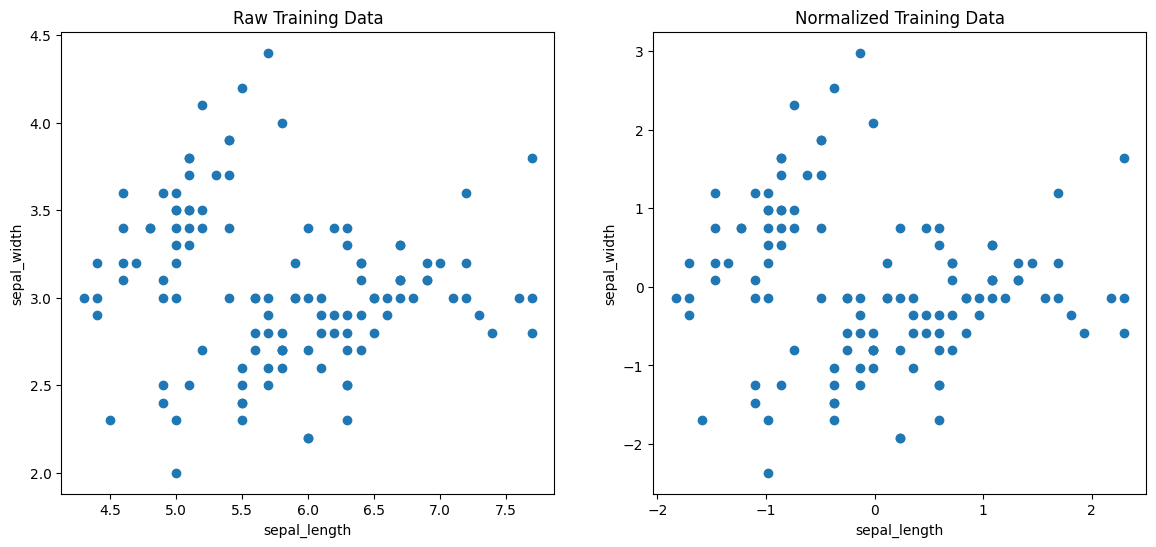

In [27]:
### your code here


mean = x_train.mean(dim=0)
std = x_train.std(dim=0)

x_train_normalized = norm_set(x_train, mean, std)
x_test_normalized = norm_set(x_test, mean, std)


# ^ raw vs normalized training sets, takes 1st and 2nd columns to plot (sepal length and sepal width)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ^Raw  
axes[0].scatter(x_train[:, 0], x_train[:, 1])
axes[0].set_title("Raw Training Data")
axes[0].set_xlabel("sepal_length")
axes[0].set_ylabel("sepal_width")

# ^Normalized 
axes[1].scatter(x_train_normalized[:, 0], x_train_normalized[:, 1])
axes[1].set_title("Normalized Training Data")
axes[1].set_xlabel("sepal_length")
axes[1].set_ylabel("sepal_width")


plt.show()






In [28]:
x_train = x_train_normalized
x_test = x_test_normalized

The dataset contains four attributes: sepal length, sepal width, petal length, and petal width. For the first binary classification example, the first two attributes are used to make the decision boundary easier to visualise.


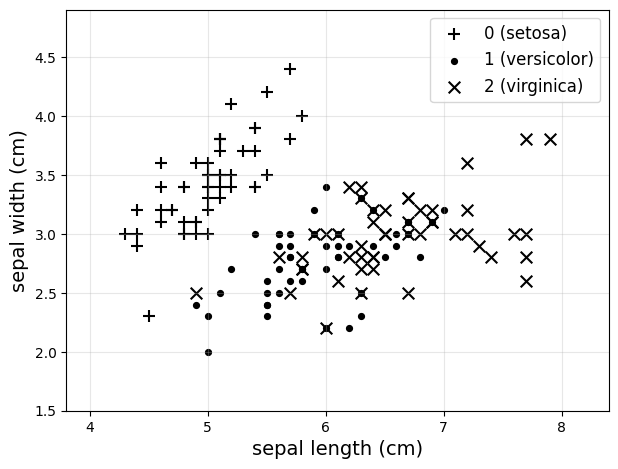

In [29]:
X = iris_db.data.iloc[:, :2]
Y = iris_db.target
marker_list = ['+', '.', 'x']
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111)
ax.set_aspect('equal')

for l in [0, 1, 2]:
  ax.scatter(
      X.loc[Y == l].iloc[:, 0],
      X.loc[Y == l].iloc[:, 1],
      marker=marker_list[l],
      s=70,
      color='black',
      label='{:d} ({:s})'.format(l, iris_db.target_names[l])
      )

ax.legend(fontsize=12)
ax.set_xlabel(iris_db.feature_names[0], fontsize=14)
ax.set_ylabel(iris_db.feature_names[1], fontsize=14)
ax.grid(alpha=0.3)
ax.set_xlim(X.iloc[:, 0].min() - 0.5, X.iloc[:, 0].max() + 0.5)
ax.set_ylim(X.iloc[:, 1].min() - 0.5, X.iloc[:, 1].max() + 0.5)
plt.show()

The plot is used to inspect whether the classes appear linearly separable using only sepal length and sepal width.


The task is first simplified to binary classification: predicting whether a sample is setosa or not setosa. The labels are converted so that setosa is represented as 1 and all other classes are represented as 0.


In [30]:
train_set_1 = x_train[:, :2]
test_set_1 = x_test[:, :2]

# add a feature for bias
train_set_1 = torch.cat([train_set_1, torch.ones(train_set_1.shape[0], 1)], dim=1)
test_set_1 = torch.cat([test_set_1, torch.ones(test_set_1.shape[0], 1)], dim=1)

setosa_train = (y_train == 0).int()
setosa_test = (y_test == 0).int()

# 2. Sigmoid Function and Logistic Regression


Logistic regression is used for classification tasks where the target values are discrete classes rather than continuous values.

For binary classification, the sigmoid function maps the model output to a value between 0 and 1:

$$h_{\theta}(x) = g(\theta^Tx) = \frac{1}{1 + e^{-\theta^Tx}}$$

This section implements the sigmoid function and a custom PyTorch logistic regression layer.


In [31]:
def sigmoid(z: torch.Tensor) -> torch.Tensor:
  ### your code here
  return 1 / (1 + torch.exp(-z))
  



In [32]:
class LogisticRegression(nn.Module):
  def __init__(self, num_features):
    super().__init__()
    self.weight = nn.Parameter(torch.zeros(1, num_features), requires_grad=False)

  def forward(self, x):
    y = 0
    ### your code here
    #^ linear transform
    linear_trans = x @ self.weight.T  
    #^ sigmoid
    y = 1 / (1 + torch.exp(-linear_trans))  
    return y


In [33]:
## test the custom layer
model = LogisticRegression(x_train.shape[1])
prediction = model(x_train)
print(prediction.shape)
print(len(x_train))


torch.Size([120, 1])
120


# 3. Binary Cross-Entropy Loss


The logistic regression model is trained using binary cross-entropy loss:

$$
J(\theta) = \frac{1}{m}\sum_{i=1}^{m}\left[-y^{(i)}\log(h_{\theta}(x^{(i)})) - (1-y^{(i)})\log(1-h_{\theta}(x^{(i)}))\right]
$$

The corresponding gradient descent update is:

$$
\theta_j = \theta_j - \alpha\frac{1}{m}\sum_{i=1}^{m}(h_{\theta}(x^{(i)}) - y^{(i)})x_j^{(i)}
$$


In [34]:
def bce(y_true: torch.Tensor, y_pred: torch.Tensor) -> torch.Tensor:
  ### your code here
    m = y_true.shape[0]  #^ no.  of samples
    # ^calc bce
    loss = -(1 / m) * torch.sum(y_true * torch.log(y_pred) + (1 - y_true) * torch.log(1 - y_pred))

    return loss


def gradient_descent_step(model: nn.Module, X: torch.Tensor, y: torch.Tensor, y_pred: torch.Tensor, lr: float) -> None:
  weight = model.weight
  N = X.shape[0]
  ### your code here
  errors = y_pred - y
  gradients = (1 / N) * (errors.T @ X)
  weight = weight - (lr * gradients)
  model.weight = nn.Parameter(weight, requires_grad=False)

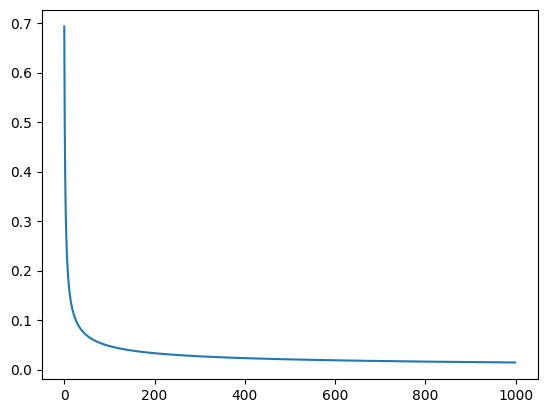

Parameter containing:
tensor([[-7.6483,  4.1452, -4.5710]])
Minimum cost: 0.014265165664255619


In [43]:
def train(model, x, y, alpha):
  cost_lst = list()
  for it in range(1000):
    prediction = model(x)
    cost = bce(y, prediction)
    cost_lst.append(cost)
    gradient_descent_step(model, x, y, prediction, alpha)
    
  display.clear_output(wait=True)
  
  plt.plot(list(range(it+1)), cost_lst)
  plt.show()
  print(model.weight)
  print('Minimum cost: {}'.format(min(cost_lst)))


model = LogisticRegression(train_set_1.shape[1])

alpha = 1 # select an appropriate lr

train(model, train_set_1, setosa_train, alpha)

# 4. Decision Boundary


This section visualises the learned decision boundary on the test set to evaluate how well the binary classifier separates setosa from the other iris classes.


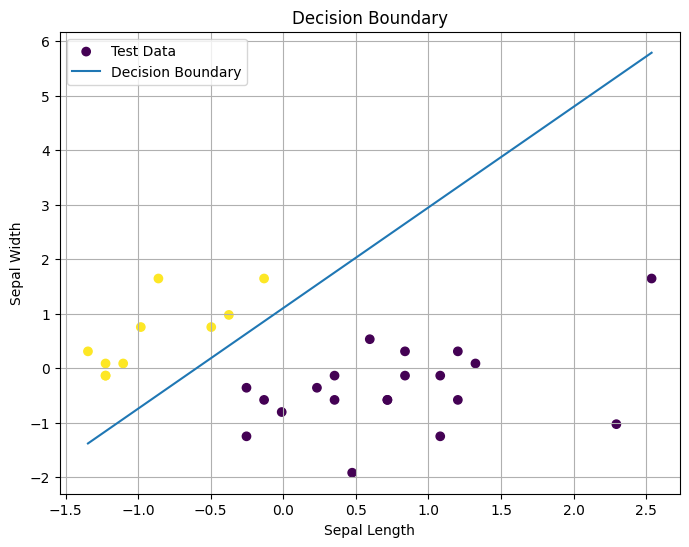

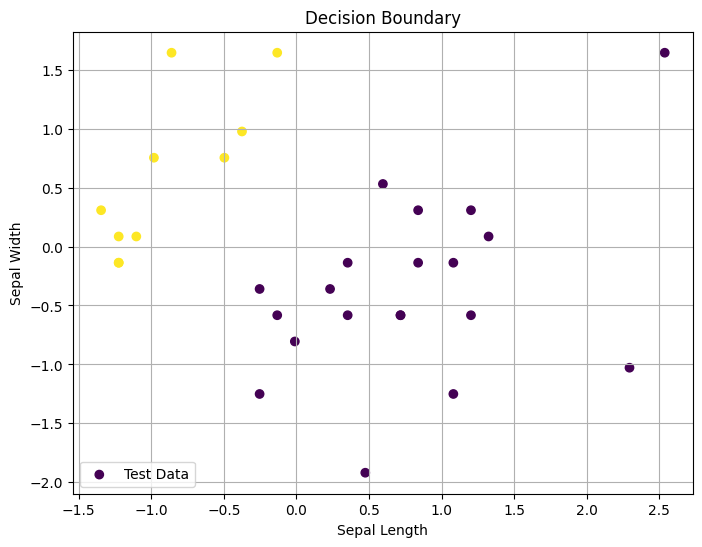

In [36]:



sepal_length_feature = model.weight[0, 0].item()  
sepal_width_feature = model.weight[0, 1].item() 
bias_term = model.weight[0, 2].item()       

#  ^x-axis range 
x_range = np.linspace(x_test[:, 0].min(), x_test[:, 0].max(), 100)


# ^Equation: x2 = -(w1/w2) * x1 - (b/w2)
decision_boundary_y = -(sepal_length_feature / sepal_width_feature) * x_range - (bias_term / sepal_width_feature)

# !plot
plt.figure(figsize=(8, 6))
plt.scatter(x_test[:, 0], x_test[:, 1], c=setosa_test.reshape(-1), label="Test Data")


plt.plot(x_range, decision_boundary_y, label="Decision Boundary")


plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("Decision Boundary")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(x_test[:, 0], x_test[:, 1], c=setosa_test.reshape(-1), label="Test Data")

plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("Decision Boundary")
plt.legend()
plt.grid()
plt.show()




# 5. Multiclass Classification

The binary classification task is extended to multiclass classification using a one-vs-all approach. Each class is represented with its own binary classifier, and all four Iris attributes are used.

The labels are converted into one-hot encoded vectors so each class can be trained separately.


In [37]:
y_train = F.one_hot(y_train.reshape(-1).long(), num_classes=3)
y_test = F.one_hot(y_test.reshape(-1).long(), num_classes=3)
print(y_test.shape)

torch.Size([30, 3])


PyTorch's built-in layers, optimisers, and binary cross-entropy loss are used for the multiclass section.


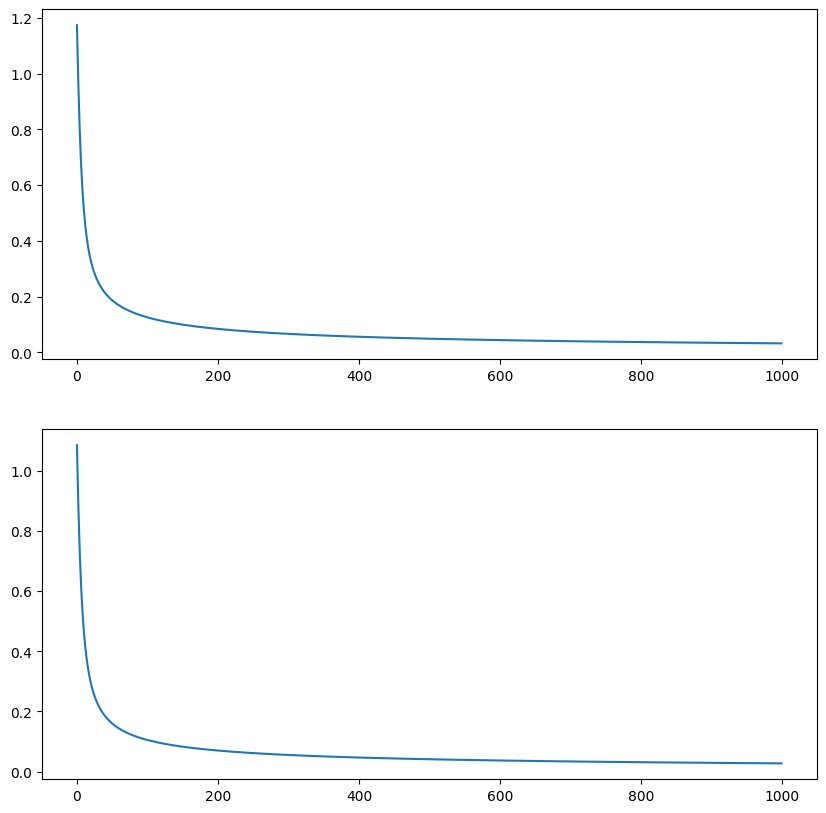

Minimum train cost: 0.03205081447958946
Minimum test cost: 0.027330735698342323


In [38]:
alpha = 0.1
setosa_model = nn.Sequential(nn.Linear(x_train.shape[1], 1, bias=False), nn.Sigmoid())
setosa_labels = y_train[:, 0].reshape(-1, 1).float()
setosa_testy = y_test[:, 0].reshape(-1, 1).float()
optimiser = optim.SGD(setosa_model.parameters(), alpha)

def train(model, x, y, test_x, test_y, optimiser, alpha):
  train_lst = list()
  test_lst = list()
  for i in range(1000):
    model.train()
    optimiser.zero_grad()
    
    pred = model(x)
    cost = F.binary_cross_entropy(pred, y, reduction='mean')
    cost.backward()
    
    train_lst.append(cost.item())

    optimiser.step()
    model.eval()
    
    with torch.no_grad():
      test_pred = model(test_x)
      test_cost = F.binary_cross_entropy(test_pred, test_y, reduction='mean')
      test_lst.append(test_cost)
      

  fig, axs = plt.subplots(2, figsize=(10, 10))
  axs[0].plot(list(range(i+1)), train_lst)
  axs[1].plot(list(range(i+1)), test_lst)

  plt.show()
  
  print('Minimum train cost: {}'.format(min(train_lst)))
  print('Minimum test cost: {}'.format(min(test_lst)))



train(setosa_model, x_train, setosa_labels, x_test, setosa_testy, optimiser, alpha)

# 6. One-vs-All Classifiers


This section trains one classifier for each Iris class: setosa, versicolor, and virginica. The performance can then be compared with the earlier two-feature binary classifier.


Setosa



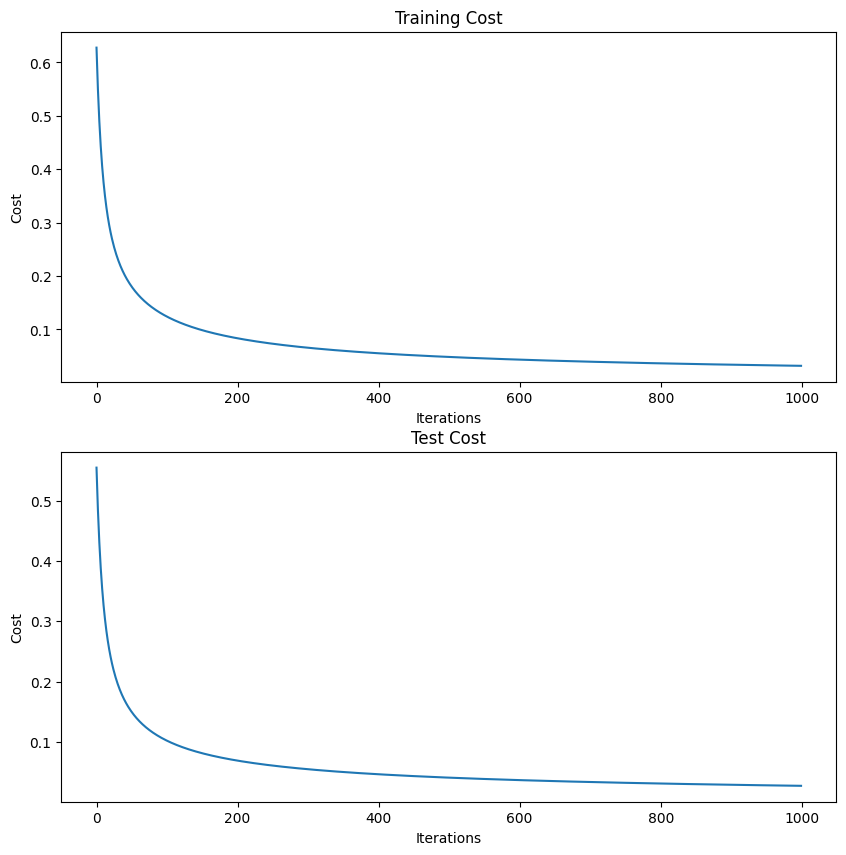

Minimum train cost: 0.03186281397938728
Minimum test cost: 0.02757815457880497
Versicolor



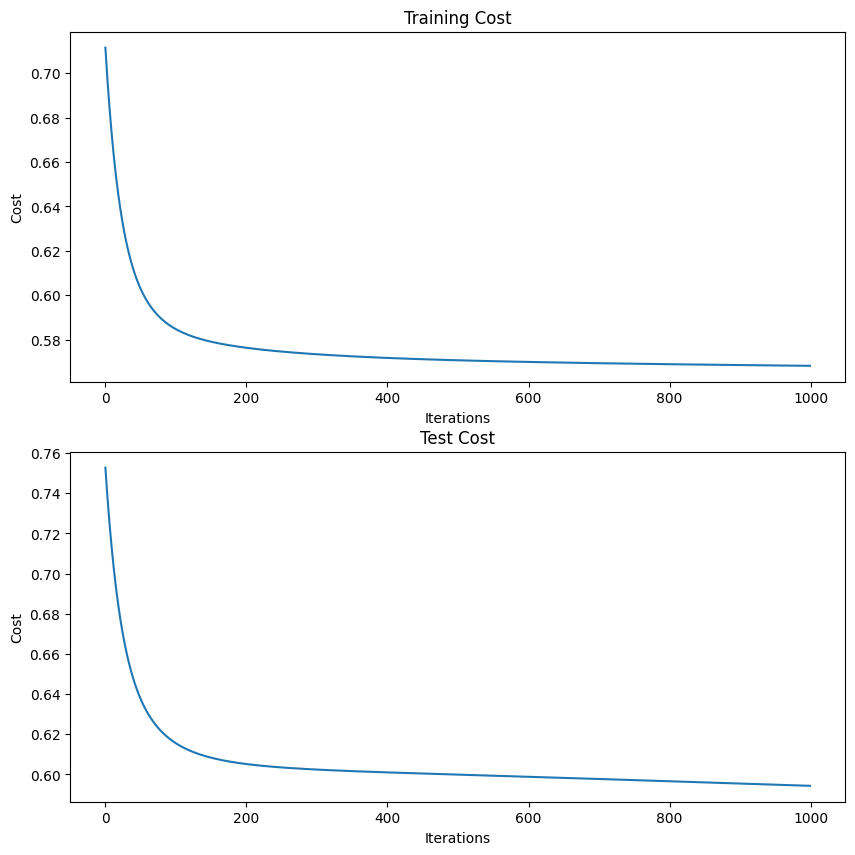

Minimum train cost: 0.5682417154312134
Minimum test cost: 0.5943567156791687
Virginica



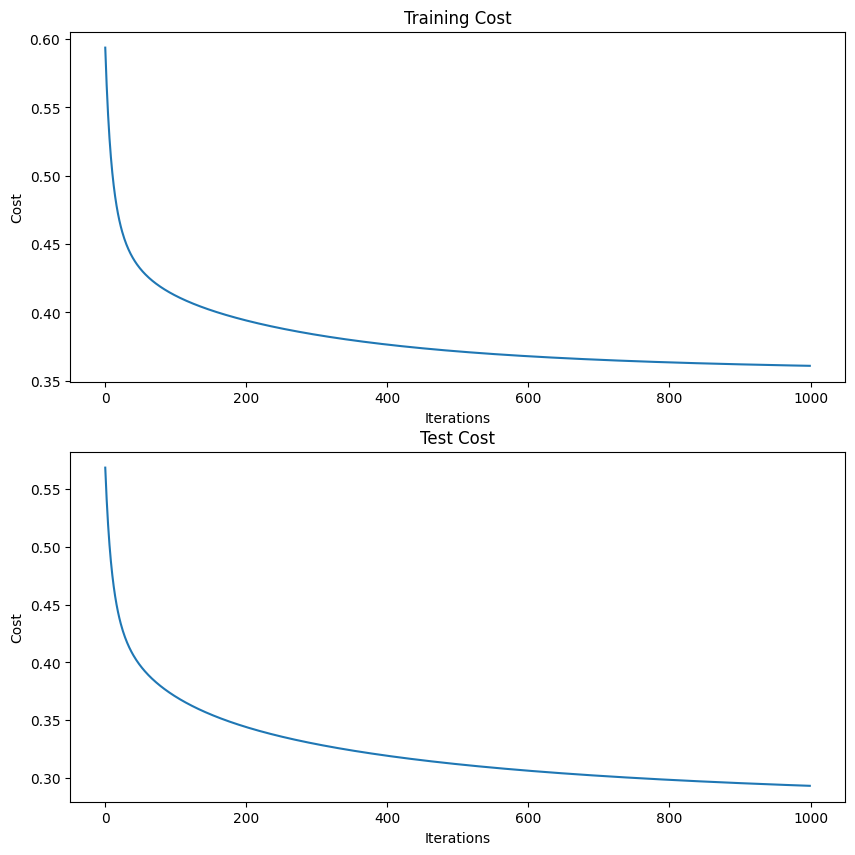

Minimum train cost: 0.36098194122314453
Minimum test cost: 0.29335126280784607


In [39]:


lr = 0.1

#^ Total features 
num_features = x_train.shape[1]

#! Instantiate 3 models
setosa_model = nn.Sequential(nn.Linear(num_features, 1, bias=False),nn.Sigmoid())
versicolor_model = nn.Sequential(nn.Linear(num_features, 1, bias=False),nn.Sigmoid())
virginica_model = nn.Sequential(nn.Linear(num_features, 1, bias=False),nn.Sigmoid())

# !Instantiate optimisers (modewl.params, lr)
setosa_optimizer = optim.SGD(setosa_model.parameters(), lr=lr)
versicolor_optimizer = optim.SGD(versicolor_model.parameters(), lr=lr)
virginica_optimizer = optim.SGD(virginica_model.parameters(), lr=lr)

#*NOTE - y tain and y test are OHE tensors.
#^ get class column (setosa = 1st, versicolor = 2nd, virginica = 3rd)> reshape to 2d > convert to float for model
setosa_train_labels = y_train[:, 0].reshape(-1, 1).float()
setosa_test_labels = y_test[:, 0].reshape(-1, 1).float()

versicolor_train_labels = y_train[:, 1].reshape(-1, 1).float()
versicolor_test_labels = y_test[:, 1].reshape(-1, 1).float()

virginica_train_labels = y_train[:, 2].reshape(-1, 1).float()
virginica_test_labels = y_test[:, 2].reshape(-1, 1).float()


#*NOTE - Basically the same from above ( train function below has been copied from the template)
def train(model, x, y, test_x, test_y, optimiser, alpha):
    train_costs = [] 
    test_costs = []   
    
    for iteration in range(1000):
        model.train()
        optimiser.zero_grad()
        
        train_predictions = model(x)
        train_cost = F.binary_cross_entropy(train_predictions, y, reduction='mean')
        train_cost.backward()
        
        train_costs.append(train_cost.item())
        
        optimiser.step()
        model.eval()
        
        with torch.no_grad():
            test_predictions = model(test_x)
            test_cost = F.binary_cross_entropy(test_predictions, test_y, reduction='mean')
            test_costs.append(test_cost.item())
    
    
    #& Plotting
    fig, axs = plt.subplots(2, figsize=(10, 10))
    axs[0].plot(list(range(iteration + 1)), train_costs)
    axs[1].plot(list(range(iteration + 1)), test_costs)
    # & Actually put labels unlike the assignment template code...
    axs[0].set_title("Training Cost")
    axs[0].set_xlabel("Iterations")
    axs[0].set_ylabel("Cost")
    
    axs[1].set_title("Test Cost")
    axs[1].set_xlabel("Iterations")
    axs[1].set_ylabel("Cost")
    
    plt.show()

    print('Minimum train cost:', min(train_costs))
    print('Minimum test cost:', min(test_costs))

print("Setosa\n")
train(
    setosa_model,
    x_train,
    setosa_train_labels,
    x_test,
    setosa_test_labels,
    setosa_optimizer,
    lr
)

print("Versicolor\n")
train(
    versicolor_model,
    x_train,
    versicolor_train_labels,
    x_test,
    versicolor_test_labels,
    versicolor_optimizer,
    lr
)


print("Virginica\n")
train(
    virginica_model,
    x_train,
    virginica_train_labels,
    x_test,
    virginica_test_labels,
    virginica_optimizer,
    lr
)


# 7. Classifier Predictions


The three trained classifiers are used to predict the class of each test sample. The results are displayed in a table with true labels, predicted labels, and class probabilities.


In [40]:

# ^ extract p from models and tensors
# print(setosa_model(x_test))
with torch.no_grad():
    setosa_P = setosa_model(x_test).squeeze()    
    versicolor_P = versicolor_model(x_test).squeeze()  
    virginica_P = virginica_model(x_test).squeeze()    

# print(setosa_P)
predicted = []
# ^Iterate sample's probabilities and choose class with highest p
for i in range(len(x_test)):
    
    setosa_prob = setosa_P[i]
    versicolor_prob = versicolor_P[i]
    virginica_prob = virginica_P[i]
    
    # ^ takes highest p to classify
    if setosa_prob > versicolor_prob and setosa_prob > virginica_prob:
        predicted.append("Setosa")
    elif versicolor_prob > setosa_prob and versicolor_prob > virginica_prob:
        predicted.append("Versicolor")
    else:
        predicted.append("Virginica")

# ^ Get true labels
true_labels = []
for i in range(len(y_test)):
    if y_test[i, 0] == 1:
        true_labels.append("Setosa")
    elif y_test[i, 1] == 1:
        true_labels.append("Versicolor")
    elif y_test[i, 2] == 1:
        true_labels.append("Virginica")


# ^ Create a DataFrame with true, predicted, probabilities for each class
results = pd.DataFrame({
    "True": true_labels,
    "Predicted": predicted,
    "Setosa P": setosa_P.numpy(),
    "Versicolor P": versicolor_P.numpy(),
    "Virginica P": virginica_P.numpy()
})

print("Predictions vs True with Class P:")
print(results)

# ^ Calculate accuracy
correct = (results["True"] == results["Predicted"]).sum()
total_samples = len(results)
accuracy = correct / total_samples

print("\nCorrect predicts:", correct)
print("Total test samples:", total_samples)
print("Accuracy:", accuracy)


Predictions vs True with Class P:
          True   Predicted  Setosa P  Versicolor P  Virginica P
0   Versicolor  Versicolor  0.031439      0.735977     0.451452
1       Setosa      Setosa  0.999956      0.172252     0.112309
2    Virginica   Virginica  0.000003      0.841358     0.947783
3   Versicolor   Virginica  0.038596      0.589173     0.704744
4   Versicolor  Versicolor  0.007737      0.768733     0.540544
5       Setosa      Setosa  0.999666      0.323149     0.084212
6   Versicolor  Versicolor  0.296620      0.551426     0.531372
7    Virginica   Virginica  0.002391      0.392186     0.970366
8   Versicolor  Versicolor  0.000491      0.918323     0.399518
9   Versicolor  Versicolor  0.078002      0.734596     0.376230
10   Virginica   Virginica  0.014600      0.349182     0.948110
11      Setosa      Setosa  0.999252      0.587641     0.022442
12      Setosa      Setosa  0.999913      0.310009     0.050437
13      Setosa      Setosa  0.999467      0.535612     0.026298
14    

The model achieves around 90% accuracy on the test set.

The incorrect predictions mainly occur between versicolor and virginica. This suggests that these two classes are harder to separate than setosa, likely because their feature values overlap more closely.

The setosa probabilities are generally much lower for non-setosa samples, indicating that the classifier has less difficulty distinguishing setosa from the other two species.


# 8. Softmax-Based Accuracy


The classifier outputs are combined and passed through a softmax function. The class with the highest softmax probability is selected as the final prediction, and accuracy is calculated against the true test labels.


In [41]:


# ^ get predicted P and squeeze to same shape
with torch.no_grad():
    setosa_P = setosa_model(x_test).squeeze()    
    versicolor_P = versicolor_model(x_test).squeeze()  
    virginica_P = virginica_model(x_test).squeeze()    

#^ stack P along 2nd dim for applying softmax on a single row 
stacked_P = torch.stack([setosa_P, versicolor_P, virginica_P], dim=1)
#^ normalise
softmaxxed_P = torch.nn.functional.softmax(stacked_P, dim=1)

#^ extract 1st, 2nd, 3rd column for corresponding class to another tensor
setosa_softmax = softmaxxed_P[:, 0]  
versicolor_softmax = softmaxxed_P[:, 1]  
virginica_softmax = softmaxxed_P[:, 2]  

# print(setosa_P)
predicted = []
# ^Iterate sample's probabilities and choose class with highest
for i in range(len(x_test)):
    
    setosa_prob = setosa_softmax[i]
    versicolor_prob = versicolor_softmax[i]
    virginica_prob = virginica_softmax[i]
    
    # ^ takes highest p to classify
    if setosa_prob > versicolor_prob and setosa_prob > virginica_prob:
        
        predicted.append("Setosa")
    elif versicolor_prob > setosa_prob and versicolor_prob > virginica_prob:
        
        predicted.append("Versicolor")
        
    else:
        predicted.append("Virginica")

# ^ Get true labels
true_labels = []
for i in range(len(y_test)):
    if y_test[i, 0] == 1:
        
        true_labels.append("Setosa")
    elif y_test[i, 1] == 1:
        
        true_labels.append("Versicolor")
    elif y_test[i, 2] == 1:
        
        true_labels.append("Virginica")


# ^ Create a DataFrame with true labels, predicted labels, and probabilities for each class
results = pd.DataFrame({
    "True": true_labels,
    "Predicted": predicted,
    "Setosa Probability": setosa_softmax.numpy(),
    "Versicolor Probability": versicolor_softmax.numpy(),
    "Virginica Probability": virginica_softmax.numpy()
})

print("Predictions vs True with Class Probabilities:")
print(results)

# ^ Calculate accuracy
correct = (results["True"] == results["Predicted"]).sum()
total_samples = len(results)
accuracy = correct / total_samples

print("\nNumber of correct predictions:", correct)
print("Total test samples:", total_samples)
print("Accuracy:", accuracy)


Predictions vs True with Class Probabilities:
          True   Predicted  Setosa Probability  Versicolor Probability  \
0   Versicolor  Versicolor            0.220027                0.445096   
1       Setosa      Setosa            0.540928                0.236413   
2    Virginica   Virginica            0.169506                0.393171   
3   Versicolor   Virginica            0.213631                0.370490   
4   Versicolor  Versicolor            0.206436                0.441857   
5       Setosa      Setosa            0.523911                0.266348   
6   Versicolor  Versicolor            0.281309                0.362948   
7    Virginica   Virginica            0.195722                0.289019   
8   Versicolor  Versicolor            0.200231                0.501350   
9   Versicolor  Versicolor            0.233881                0.450972   
10   Virginica   Virginica            0.202397                0.282821   
11      Setosa      Setosa            0.490415                0.32

# 9. The XOR Problem


The XOR problem is used to demonstrate a limitation of logistic regression. Because the XOR classes are not linearly separable, a single logistic regression decision boundary cannot correctly separate all points.


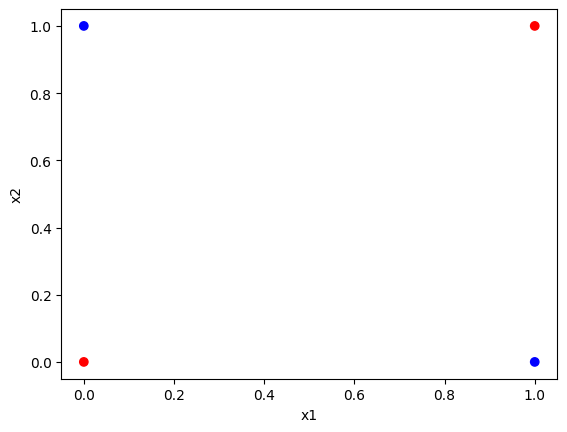

In [42]:
x1 = [0, 0, 1, 1]
x2 = [0, 1, 0, 1]
y = [0, 1, 1, 0]

c_map = ['r', 'b', 'b', 'r']
plt.scatter(x1, x2, c=c_map)
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()


